In [1]:
"""
Fragment 1 — Data Loading & Feature Extraction (Flattened Pixels)
==================================================================
SVM Binary Mould Classification Pipeline — Mold vs No Mold

- Loads train, val and test data from disk
- Resizes all images to IMG_SIZE
- Flattens each image to a 1D feature vector
- Normalises pixel values to [0, 1]
- No augmentation applied to val or test
- Train data loaded from augmented folder
- Binary labels: 0 / 1
"""

import os
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.preprocessing import LabelEncoder

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies Binary\Mould Binary Classification"
AUG_DIR    = os.path.join(DATA_DIR, "augmented")
VALID_DIR  = os.path.join(DATA_DIR, "val")
TEST_DIR   = os.path.join(DATA_DIR, "test")

IMG_SIZE   = (16, 16)     # smaller than DL models — SVM cannot handle
                           # 224x224x3 = 150528 features efficiently
IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

# ── Step 1: Image loader ──────────────────────────────────────────────────────

def load_flat_dataset(folder: str, img_size: tuple) -> tuple:
    """
    Loads all images from a class-structured folder.
    Resizes, flattens and normalises each image.
    Returns X (n_samples, n_features) and y (n_samples,) as strings.
    """
    X, y = [], []

    folder_path = Path(folder)
    classes     = sorted([d.name for d in folder_path.iterdir() if d.is_dir()])

    for cls in classes:
        cls_path = folder_path / cls
        images   = [
            f for f in cls_path.iterdir()
            if f.suffix.lower() in IMG_EXTS
        ]

        for img_path in images:
            try:
                img = Image.open(img_path).convert("RGB")
                img = img.resize(img_size)
                arr = np.array(img, dtype=np.float32) / 255.0
                X.append(arr.flatten())
                y.append(cls)
            except Exception as e:
                print(f"  ⚠️  Skipped {img_path.name}: {e}")

    return np.array(X), np.array(y)

# ── Step 2: Load all three sets ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 1 — Loading & Flattening Images")
print("=" * 60)
print(f"  Pipeline      : Binary — Mold vs No Mold")
print(f"  Image size    : {IMG_SIZE}")
print(f"  Features      : {IMG_SIZE[0] * IMG_SIZE[1] * 3}")
print("=" * 60)

print(f"\n  Loading train (augmented)...")
X_train_raw, y_train_raw = load_flat_dataset(AUG_DIR,   IMG_SIZE)
print(f"  ✓ Train : {X_train_raw.shape}")

print(f"\n  Loading val...")
X_val_raw,   y_val_raw   = load_flat_dataset(VALID_DIR, IMG_SIZE)
print(f"  ✓ Val   : {X_val_raw.shape}")

print(f"\n  Loading test...")
X_test_raw,  y_test_raw  = load_flat_dataset(TEST_DIR,  IMG_SIZE)
print(f"  ✓ Test  : {X_test_raw.shape}")

# ── Step 3: Encode labels ─────────────────────────────────────────────────────

label_encoder = LabelEncoder()
label_encoder.fit(y_train_raw)

y_train = label_encoder.transform(y_train_raw)
y_val   = label_encoder.transform(y_val_raw)
y_test  = label_encoder.transform(y_test_raw)

CLASS_NAMES = list(label_encoder.classes_)
NUM_CLASSES = len(CLASS_NAMES)

# ── Step 4: Summary ───────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("  Fragment 1 — Data Ready")
print("=" * 60)
print(f"  Pipeline      : Binary — Mold vs No Mold")
print(f"  Architecture  : SVM (flattened pixels)")
print(f"  Train samples : {X_train_raw.shape[0]}")
print(f"  Val samples   : {X_val_raw.shape[0]}")
print(f"  Test samples  : {X_test_raw.shape[0]}")
print(f"  Features      : {X_train_raw.shape[1]}")
print(f"  Classes       : {CLASS_NAMES}")
print(f"  Class indices : {dict(zip(CLASS_NAMES, label_encoder.transform(CLASS_NAMES)))}")
print("=" * 60)

print("\n  ✓ Fragment 1 complete.")
print("     Proceed to Fragment 2 — SVM Training & 5-Run Analysis.\n")

  Fragment 1 — Loading & Flattening Images
  Pipeline      : Binary — Mold vs No Mold
  Image size    : (16, 16)
  Features      : 768

  Loading train (augmented)...
  ✓ Train : (58813, 768)

  Loading val...
  ✓ Val   : (648, 768)

  Loading test...
  ✓ Test  : (649, 768)

  Fragment 1 — Data Ready
  Pipeline      : Binary — Mold vs No Mold
  Architecture  : SVM (flattened pixels)
  Train samples : 58813
  Val samples   : 648
  Test samples  : 649
  Features      : 768
  Classes       : ['Mold', 'No mold']
  Class indices : {'Mold': 0, 'No mold': 1}

  ✓ Fragment 1 complete.
     Proceed to Fragment 2 — SVM Training & 5-Run Analysis.



  Fragment 2 — SVM Binary 5-Run Training
  Pipeline     : Binary — Mold vs No Mold
  Kernel       : linear
  C            : 1.0
  Gamma        : scale
  Threshold    : 0.5
  Seeds        : [27, 42, 99, 123, 256]
  Features     : 768

  RUN 1 / 5  —  SVM Binary
  Seed : 27

  Training SVM...
  ✓ Training complete

  Run 1 Results
    Accuracy     : 0.7473
    Precision    : 0.7796
    Sensitivity  : 0.7796
    Specificity  : 0.7040
    F1 Score     : 0.7796
    AUC          : 0.8014
    TP=290  TN=195  FP=82  FN=82


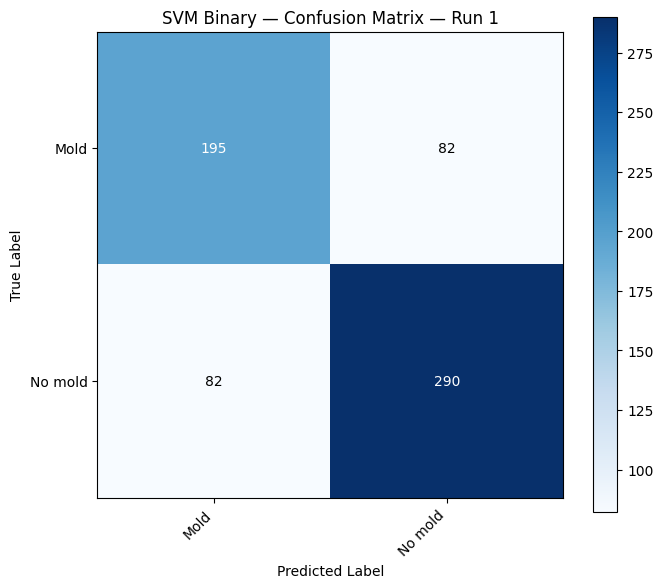

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_confusion_matrix_run1.png


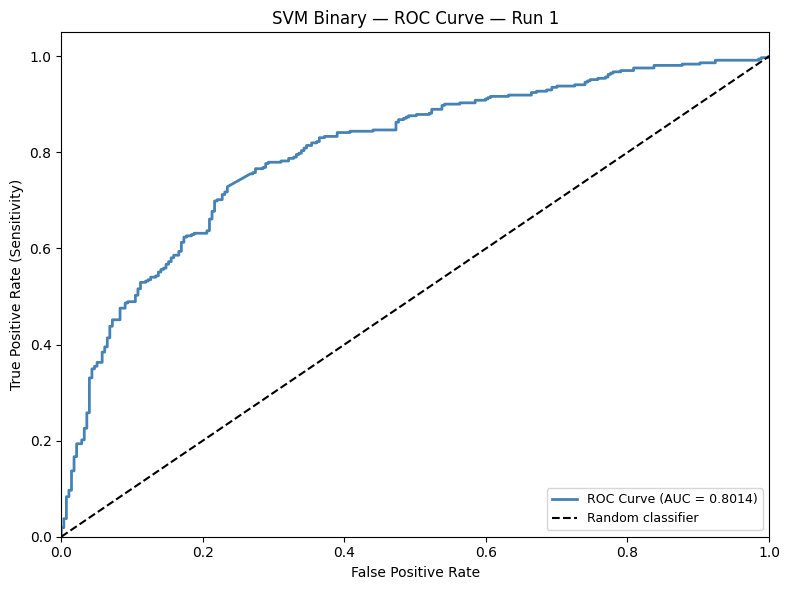

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_roc_curve_run1.png


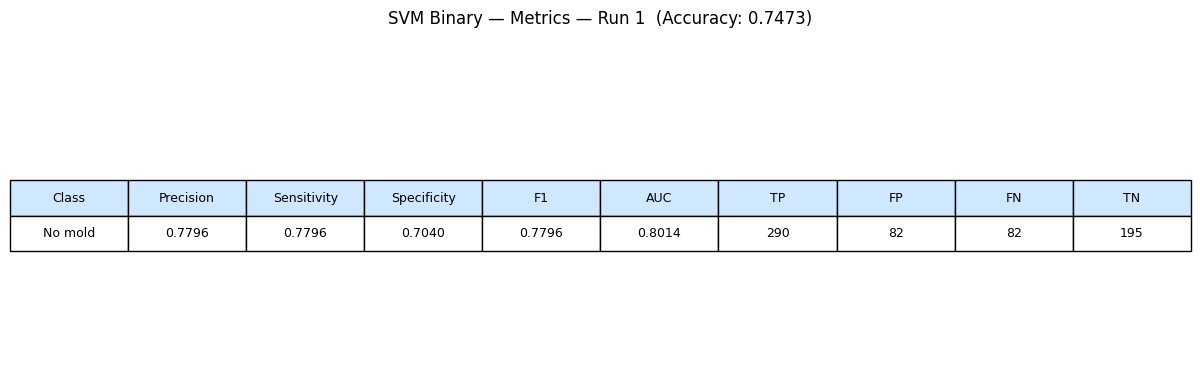

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_metrics_table_run1.png

  RUN 2 / 5  —  SVM Binary
  Seed : 42

  Training SVM...
  ✓ Training complete

  Run 2 Results
    Accuracy     : 0.7350
    Precision    : 0.7632
    Sensitivity  : 0.7796
    Specificity  : 0.6751
    F1 Score     : 0.7713
    AUC          : 0.8117
    TP=290  TN=187  FP=90  FN=82


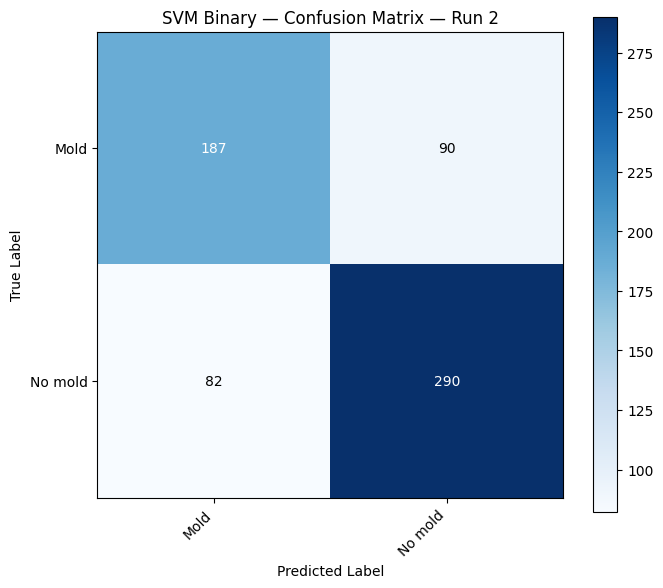

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_confusion_matrix_run2.png


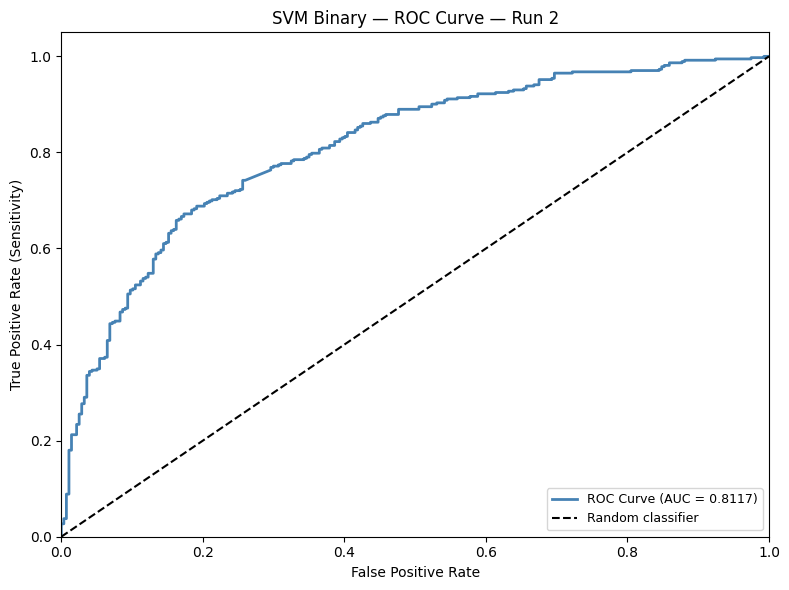

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_roc_curve_run2.png


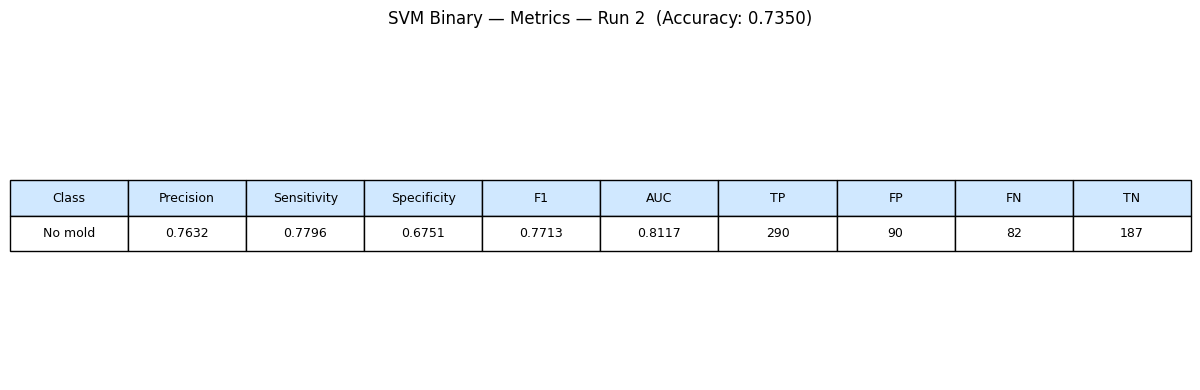

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_metrics_table_run2.png

  RUN 3 / 5  —  SVM Binary
  Seed : 99

  Training SVM...
  ✓ Training complete

  Run 3 Results
    Accuracy     : 0.7750
    Precision    : 0.8038
    Sensitivity  : 0.8038
    Specificity  : 0.7365
    F1 Score     : 0.8038
    AUC          : 0.8238
    TP=299  TN=204  FP=73  FN=73


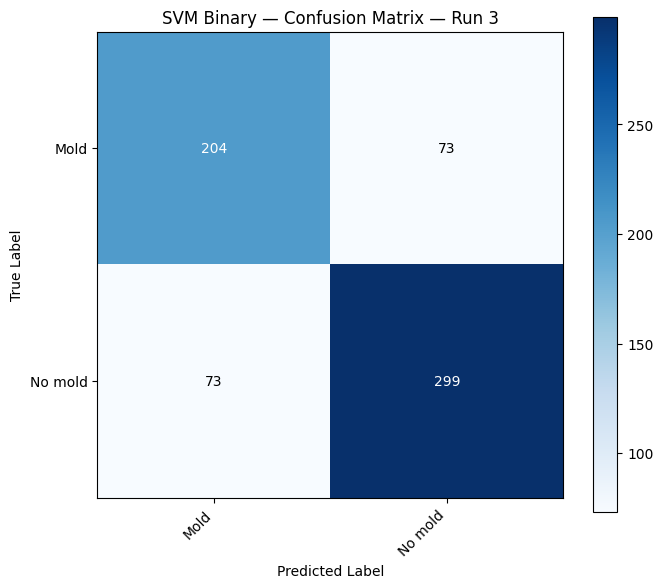

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_confusion_matrix_run3.png


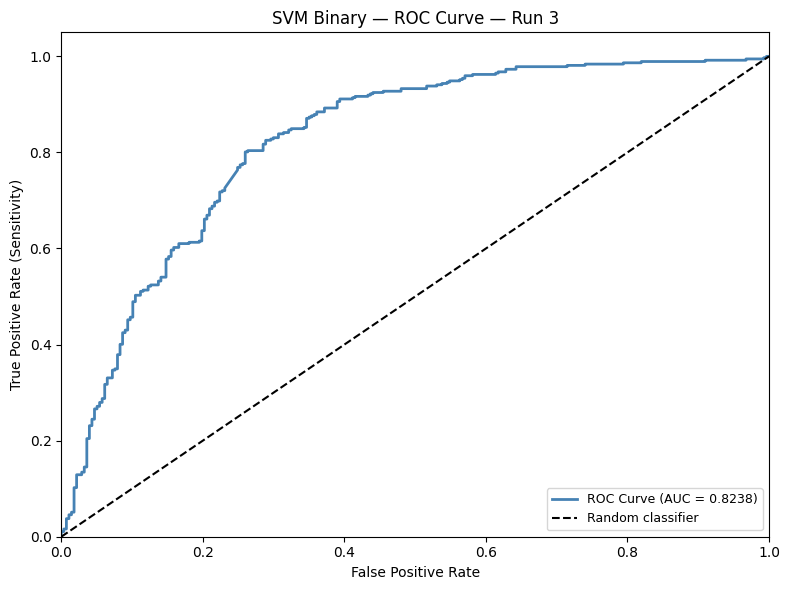

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_roc_curve_run3.png


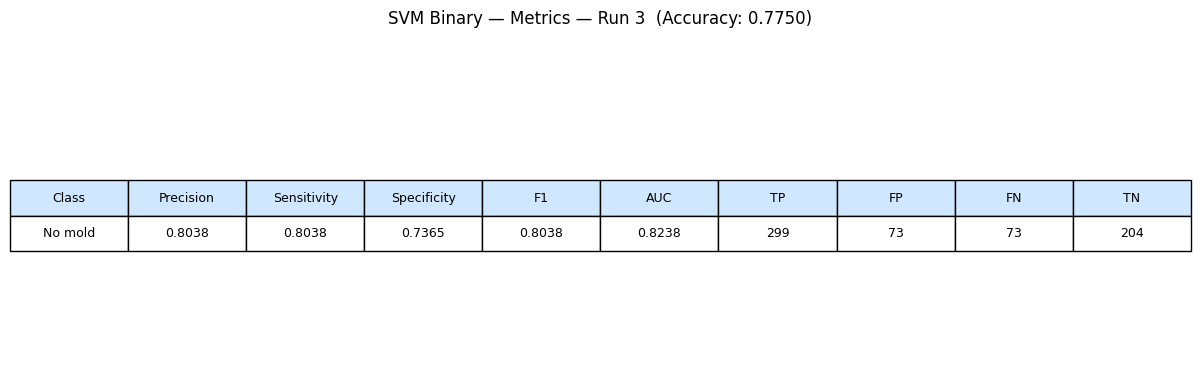

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_metrics_table_run3.png

  RUN 4 / 5  —  SVM Binary
  Seed : 123

  Training SVM...
  ✓ Training complete

  Run 4 Results
    Accuracy     : 0.7334
    Precision    : 0.7803
    Sensitivity  : 0.7446
    Specificity  : 0.7184
    F1 Score     : 0.7620
    AUC          : 0.7964
    TP=277  TN=199  FP=78  FN=95


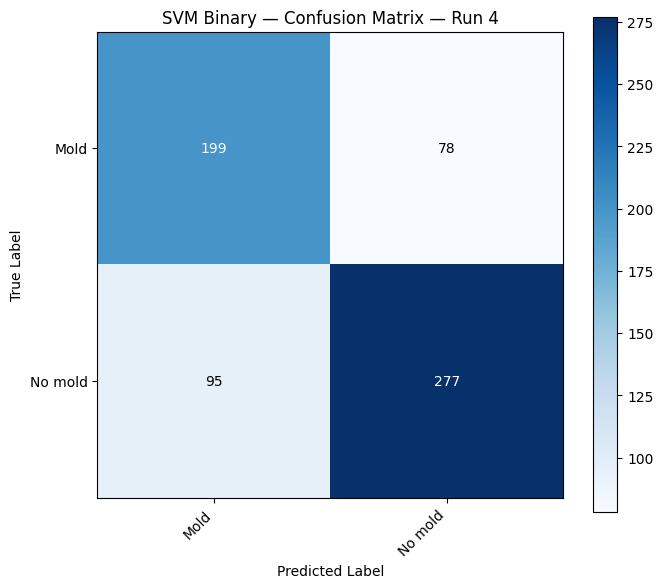

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_confusion_matrix_run4.png


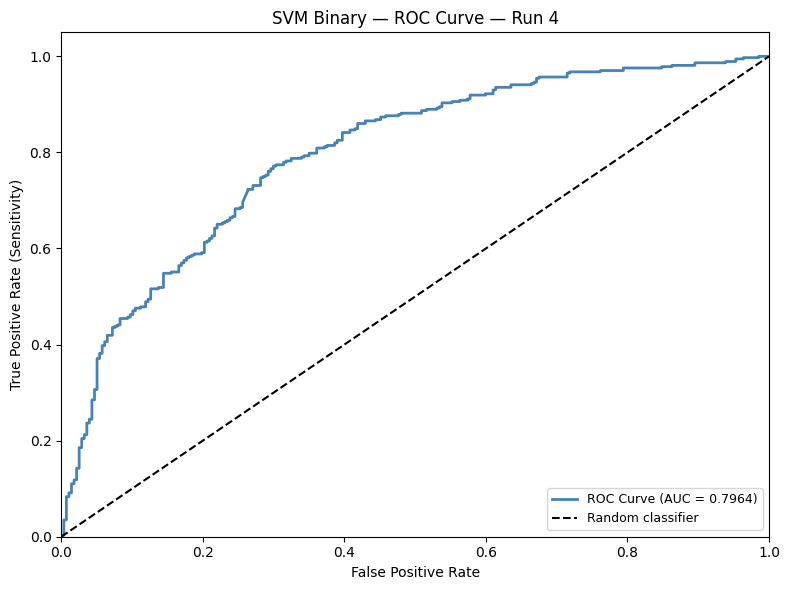

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_roc_curve_run4.png


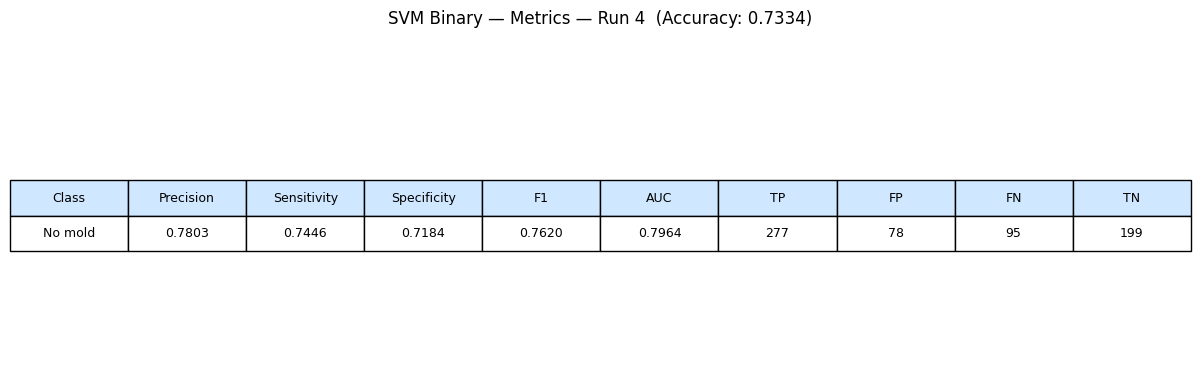

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_metrics_table_run4.png

  RUN 5 / 5  —  SVM Binary
  Seed : 256

  Training SVM...
  ✓ Training complete

  Run 5 Results
    Accuracy     : 0.7704
    Precision    : 0.7927
    Sensitivity  : 0.8118
    Specificity  : 0.7148
    F1 Score     : 0.8021
    AUC          : 0.8331
    TP=302  TN=198  FP=79  FN=70


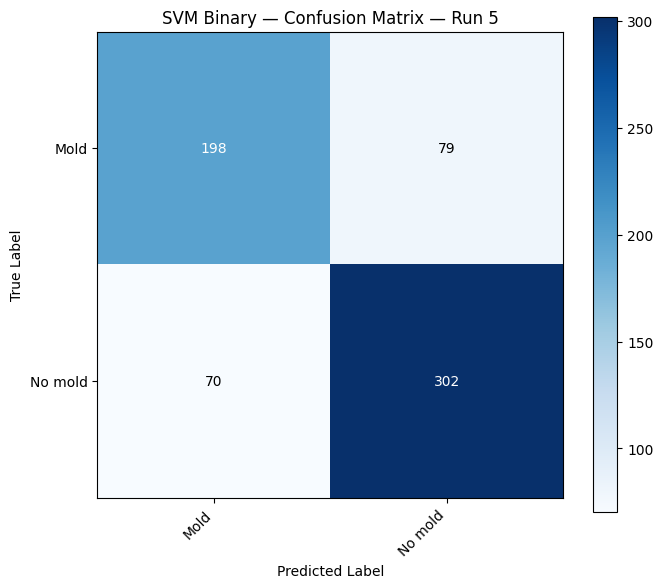

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_confusion_matrix_run5.png


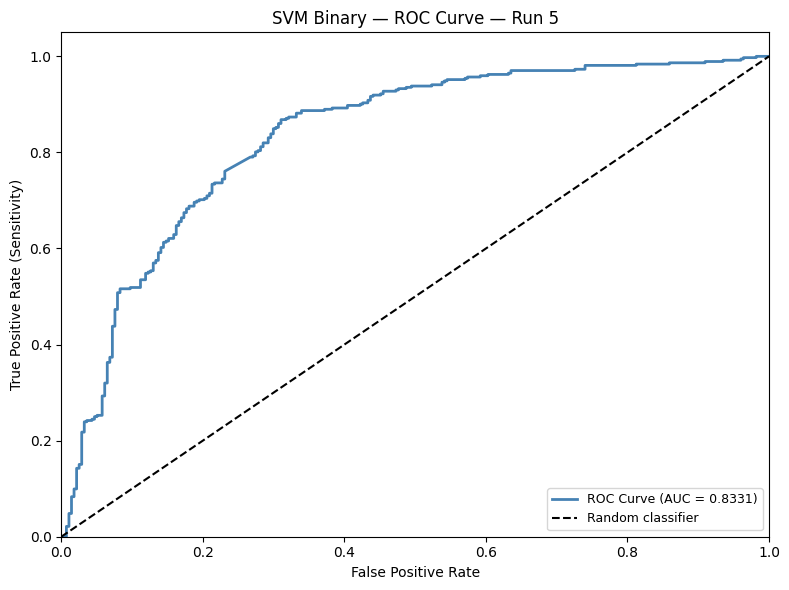

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_roc_curve_run5.png


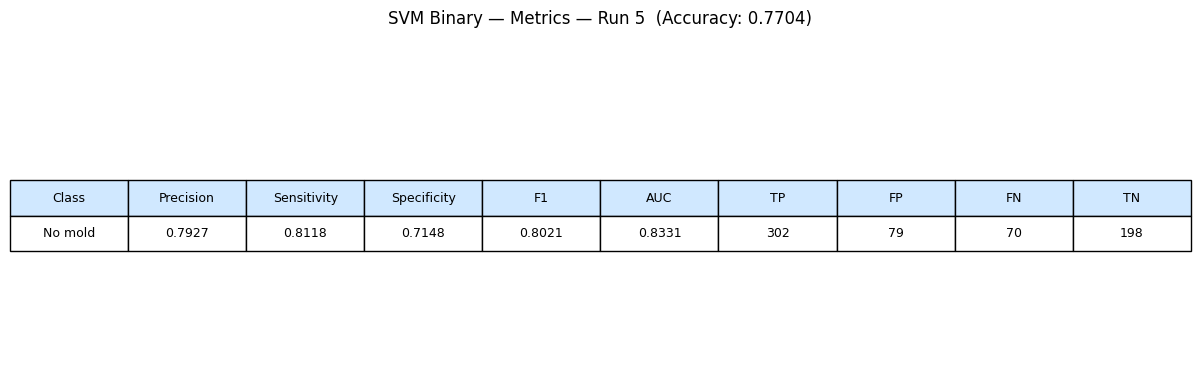

  Saved: D:\Mold Studies Binary\Models\plots\svm_flat_binary\svm_flat_binary_metrics_table_run5.png

  PER-RUN RESULTS — SVM Binary (Flattened Pixels)
  Run       Seed    Accuracy   Precision   Sensitivity   Specificity  F1 Score       AUC
──────────────────────────────────────────────────────────────────────────────────────────────
  1           27      0.7473      0.7796        0.7796        0.7040    0.7796    0.8014
  2           42      0.7350      0.7632        0.7796        0.6751    0.7713    0.8117
  3           99      0.7750      0.8038        0.8038        0.7365    0.8038    0.8238
  4          123      0.7334      0.7803        0.7446        0.7184    0.7620    0.7964
  5          256      0.7704      0.7927        0.8118        0.7148    0.8021    0.8331
──────────────────────────────────────────────────────────────────────────────────────────────

────────────────────────────  Statistical Summary  ────────────────────────────
  Metric              Mean       Std       M

In [2]:
"""
Fragment 2 — SVM Training, 5-Run Statistical Analysis & Evaluation
===================================================================
SVM Binary Mould Classification Pipeline — Mold vs No Mold

- Trains SVM 5 times using different random seeds
- Each run shuffles train data differently before fitting
- Computes full binary metrics per run on test set
- Computes confidence intervals across 5 runs
- Saves results for cross-model comparison
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
)
import scipy.stats as stats

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies Binary\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots", "svm_flat_binary")
TOTAL_RUNS = 5
SEEDS      = [27, 42, 99, 123, 256]

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# ── SVM Parameters ────────────────────────────────────────────────────────────

SVM_KERNEL = "linear"
SVM_C      = 1.0
SVM_GAMMA  = "scale"

THRESHOLD  = 0.5

# ── Step 1: Helper Functions ──────────────────────────────────────────────────

def compute_metrics_binary(y_true, y_pred, y_prob):
    """
    Computes full binary evaluation metrics.
    y_prob is the probability for the positive class (column 1).
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    precision   = tp / (tp + fp + 1e-7)
    recall      = tp / (tp + fn + 1e-7)
    specificity = tn / (tn + fp + 1e-7)
    f1          = 2 * precision * recall / (precision + recall + 1e-7)
    accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-7)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)

    return {
        "cm"         : cm,
        "tp"         : int(tp),
        "tn"         : int(tn),
        "fp"         : int(fp),
        "fn"         : int(fn),
        "accuracy"   : accuracy,
        "precision"  : precision,
        "recall"     : recall,
        "specificity": specificity,
        "f1"         : f1,
        "fpr"        : fpr,
        "tpr"        : tpr,
        "auc"        : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)
    ax.set(
        xticks      = np.arange(NUM_CLASSES),
        yticks      = np.arange(NUM_CLASSES),
        xticklabels = CLASS_NAMES,
        yticklabels = CLASS_NAMES,
        title       = f"SVM Binary — Confusion Matrix — Run {run_idx}",
        ylabel      = "True Label",
        xlabel      = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"svm_flat_binary_confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_roc_curve(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        metrics["fpr"],
        metrics["tpr"],
        color = "steelblue",
        lw    = 2,
        label = f"ROC Curve (AUC = {metrics['auc']:.4f})"
    )
    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"SVM Binary — ROC Curve — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate (Sensitivity)",
        xlim   = [0.0, 1.0],
        ylim   = [0.0, 1.05],
    )
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"svm_flat_binary_roc_curve_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    plt.close()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")
    rows = [[
        CLASS_NAMES[1],
        f"{metrics['precision']:.4f}",
        f"{metrics['recall']:.4f}",
        f"{metrics['specificity']:.4f}",
        f"{metrics['f1']:.4f}",
        f"{metrics['auc']:.4f}",
        f"{metrics['tp']}",
        f"{metrics['fp']}",
        f"{metrics['fn']}",
        f"{metrics['tn']}",
    ]]
    col_labels = ["Class", "Precision", "Sensitivity",
                  "Specificity", "F1", "AUC",
                  "TP", "FP", "FN", "TN"]
    table = ax.table(
        cellText  = rows,
        colLabels = col_labels,
        loc       = "center",
        cellLoc   = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 2.0)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor("#d0e8ff")
    ax.set_title(
        f"SVM Binary — Metrics — Run {run_idx}  "
        f"(Accuracy: {metrics['accuracy']:.4f})",
        fontsize=12, pad=20
    )
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"svm_flat_binary_metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved: {path}")

# ── Step 2: 5-Run Training Loop ───────────────────────────────────────────────

print("=" * 60)
print("  Fragment 2 — SVM Binary 5-Run Training")
print("=" * 60)
print(f"  Pipeline     : Binary — Mold vs No Mold")
print(f"  Kernel       : {SVM_KERNEL}")
print(f"  C            : {SVM_C}")
print(f"  Gamma        : {SVM_GAMMA}")
print(f"  Threshold    : {THRESHOLD}")
print(f"  Seeds        : {SEEDS}")
print(f"  Features     : {X_train_raw.shape[1]}")
print("=" * 60)

all_metrics     = []
all_run_results = []

for run_idx, seed in enumerate(SEEDS, 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}  —  SVM Binary")
    print(f"  Seed : {seed}")
    print(f"{'='*60}\n")

    # ── Shuffle train data with this run's seed ────────────────────────────────
    MAX_TRAIN = 3000

    rng     = np.random.RandomState(seed)
    indices = rng.permutation(len(X_train_raw))[:MAX_TRAIN]
    X_tr    = X_train_raw[indices]
    y_tr    = y_train[indices]

    # ── Scale features ─────────────────────────────────────────────────────────
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_test_raw)

    # ── Train SVM ──────────────────────────────────────────────────────────────
    print(f"  Training SVM...")
    svm = SVC(
        kernel       = SVM_KERNEL,
        C            = SVM_C,
        gamma        = SVM_GAMMA,
        probability  = True,
        random_state = seed,
    )
    svm.fit(X_tr_sc, y_tr)
    print(f"  ✓ Training complete")

    # ── Evaluate on test set ───────────────────────────────────────────────────
    y_pred = svm.predict(X_te_sc)
    y_prob = svm.predict_proba(X_te_sc)[:, 1]   # probability of positive class

    metrics         = compute_metrics_binary(y_test, y_pred, y_prob)
    metrics["run"]  = run_idx
    metrics["seed"] = seed
    all_metrics.append(metrics)

    all_run_results.append({
        "run"        : run_idx,
        "seed"       : seed,
        "accuracy"   : metrics["accuracy"],
        "precision"  : metrics["precision"],
        "recall"     : metrics["recall"],
        "specificity": metrics["specificity"],
        "f1"         : metrics["f1"],
        "auc"        : metrics["auc"],
    })

    print(f"\n  Run {run_idx} Results")
    print(f"    Accuracy     : {metrics['accuracy']:.4f}")
    print(f"    Precision    : {metrics['precision']:.4f}")
    print(f"    Sensitivity  : {metrics['recall']:.4f}")
    print(f"    Specificity  : {metrics['specificity']:.4f}")
    print(f"    F1 Score     : {metrics['f1']:.4f}")
    print(f"    AUC          : {metrics['auc']:.4f}")
    print(f"    TP={metrics['tp']}  TN={metrics['tn']}  "
          f"FP={metrics['fp']}  FN={metrics['fn']}")

    plot_confusion_matrix(metrics["cm"],  run_idx, PLOT_DIR)
    plot_roc_curve(metrics,               run_idx, PLOT_DIR)
    plot_metrics_table(metrics,           run_idx, PLOT_DIR)

# ── Step 3: Per-Run Summary Table ─────────────────────────────────────────────

col_run  = 6
col_seed = 8
col_acc  = 12
col_prec = 12
col_sens = 14
col_spec = 14
col_f1   = 10
col_auc  = 10

divider = "=" * (col_run + col_seed + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)
thin    = "─" * (col_run + col_seed + col_acc + col_prec +
                 col_sens + col_spec + col_f1 + col_auc + 8)

print(f"\n{divider}")
print("  PER-RUN RESULTS — SVM Binary (Flattened Pixels)")
print(divider)
print(
    f"  {'Run':<{col_run}}"
    f"{'Seed':>{col_seed}}"
    f"{'Accuracy':>{col_acc}}"
    f"{'Precision':>{col_prec}}"
    f"{'Sensitivity':>{col_sens}}"
    f"{'Specificity':>{col_spec}}"
    f"{'F1 Score':>{col_f1}}"
    f"{'AUC':>{col_auc}}"
)
print(thin)

for r in all_run_results:
    print(
        f"  {r['run']:<{col_run}}"
        f"{r['seed']:>{col_seed}}"
        f"{r['accuracy']:>{col_acc}.4f}"
        f"{r['precision']:>{col_prec}.4f}"
        f"{r['recall']:>{col_sens}.4f}"
        f"{r['specificity']:>{col_spec}.4f}"
        f"{r['f1']:>{col_f1}.4f}"
        f"{r['auc']:>{col_auc}.4f}"
    )

print(thin)

# ── Step 4: Statistical Summary with Confidence Intervals ─────────────────────

print(f"\n{'─'*28}  Statistical Summary  {'─'*28}")
print(
    f"  {'Metric':<14}"
    f"{'Mean':>10}"
    f"{'Std':>10}"
    f"{'Min':>10}"
    f"{'Max':>10}"
    f"{'95% CI':>20}"
)
print(thin)

stat_metrics = {
    "Accuracy"   : [r["accuracy"]    for r in all_run_results],
    "Precision"  : [r["precision"]   for r in all_run_results],
    "Sensitivity": [r["recall"]      for r in all_run_results],
    "Specificity": [r["specificity"] for r in all_run_results],
    "F1 Score"   : [r["f1"]          for r in all_run_results],
    "AUC"        : [r["auc"]         for r in all_run_results],
}

for label, vals in stat_metrics.items():
    vals = np.array(vals)
    mean = np.mean(vals)
    std  = np.std(vals)
    mn   = np.min(vals)
    mx   = np.max(vals)
    ci   = stats.t.interval(
               0.95,
               df    = len(vals) - 1,
               loc   = mean,
               scale = stats.sem(vals)
           )
    print(
        f"  {label:<14}"
        f"{mean:>10.4f}"
        f"{std:>10.4f}"
        f"{mn:>10.4f}"
        f"{mx:>10.4f}"
        f"  [{ci[0]:.4f}, {ci[1]:.4f}]"
    )

print(divider)

# ── Step 5: Best Run ──────────────────────────────────────────────────────────

best_run = max(all_run_results, key=lambda x: x["auc"])

print(f"\n  Best run     : Run {best_run['run']} (by AUC)  seed={best_run['seed']}")
print(f"  Accuracy     : {best_run['accuracy']:.4f}")
print(f"  Sensitivity  : {best_run['recall']:.4f}")
print(f"  Specificity  : {best_run['specificity']:.4f}")
print(f"  F1 Score     : {best_run['f1']:.4f}")
print(f"  AUC          : {best_run['auc']:.4f}")

# ── Step 6: Expose for cross-model comparison ─────────────────────────────────

svm_flat_binary_all_metrics     = all_metrics
svm_flat_binary_all_run_results = all_run_results

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 2 complete.")
print(f"     svm_flat_binary_all_metrics and")
print(f"     svm_flat_binary_all_run_results are ready.\n")

In [1]:
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import numpy as np
import os

SAVE_DIR  = r"D:\Mold Studies Binary\Models"
XLSX_PATH = os.path.join(SAVE_DIR, "binary_results_summary.xlsx")

# ── Colours ───────────────────────────────────────────────────────────────────
C_FLAT_HDR   = "7B2C2C"   # dark red    — flat baseline section
C_DL_HDR     = "1F4E79"   # dark blue   — DL section
C_HYB_HDR    = "375623"   # dark green  — hybrid section
C_COL_HDR    = "2E4057"   # dark grey   — column names
C_MEAN       = "DDEBF7"   # light blue  — mean/std rows
C_BEST       = "E2EFDA"   # light green — best run
C_ALT1       = "EEF4FB"   # very light blue — alternating
C_ALT2       = "F0F7EE"   # very light green
C_ALT3       = "FDF0F0"   # very light red
C_WHITE      = "FFFFFF"

def fill(c):
    return PatternFill("solid", fgColor=c)

def bfont(white=True, size=11):
    return Font(bold=True, color="FFFFFF" if white else "000000", size=size)

def centre():
    return Alignment(horizontal="center", vertical="center", wrap_text=True)

def border():
    s = Side(style="thin")
    return Border(left=s, right=s, top=s, bottom=s)

def hdr(ws, r, c, txt, bg, white=True, size=11):
    cell = ws.cell(row=r, column=c, value=txt)
    cell.fill = fill(bg); cell.font = bfont(white, size)
    cell.alignment = centre(); cell.border = border()

def cel(ws, r, c, val, bg=C_WHITE, bold=False):
    if isinstance(val, float): val = round(val, 4)
    cell = ws.cell(row=r, column=c, value=val)
    cell.fill = fill(bg)
    cell.font = Font(bold=bold)
    cell.alignment = centre(); cell.border = border()

METRICS = ["accuracy","precision","recall","specificity","f1","auc"]
MLABELS = ["Accuracy","Precision","Sensitivity","Specificity","F1 Score","AUC"]

def stats(runs, key):
    v = [x[key] for x in runs]
    return np.mean(v), np.std(v), np.min(v), np.max(v)

def best(runs):
    return max(runs, key=lambda x: x["auc"])

# ── All model data ─────────────────────────────────────────────────────────────

# ── 1. Flat Baselines ─────────────────────────────────────────────────────────
flat_svm_runs = [
    {"run":1,"seed":27, "accuracy":0.7473,"precision":0.8077,"recall":0.7339,"specificity":0.7653,"f1":0.7690,"auc":0.8308},
    {"run":2,"seed":42, "accuracy":0.7812,"precision":0.8230,"recall":0.7876,"specificity":0.7726,"f1":0.8049,"auc":0.8400},
    {"run":3,"seed":99, "accuracy":0.7242,"precision":0.7615,"recall":0.7554,"specificity":0.6823,"f1":0.7584,"auc":0.7893},
    {"run":4,"seed":123,"accuracy":0.7658,"precision":0.8005,"recall":0.7876,"specificity":0.7365,"f1":0.7940,"auc":0.8260},
    {"run":5,"seed":256,"accuracy":0.7535,"precision":0.7704,"recall":0.8118,"specificity":0.6751,"f1":0.7906,"auc":0.8107},
]

flat_knn_runs = [
    {"run":1,"seed":27, "accuracy":0.9384,"precision":0.9323,"recall":0.9624,"specificity":0.9061,"f1":0.9471,"auc":0.9746},
    {"run":2,"seed":42, "accuracy":0.9384,"precision":0.9323,"recall":0.9624,"specificity":0.9061,"f1":0.9471,"auc":0.9746},
    {"run":3,"seed":99, "accuracy":0.9384,"precision":0.9323,"recall":0.9624,"specificity":0.9061,"f1":0.9471,"auc":0.9746},
    {"run":4,"seed":123,"accuracy":0.9384,"precision":0.9323,"recall":0.9624,"specificity":0.9061,"f1":0.9471,"auc":0.9746},
    {"run":5,"seed":256,"accuracy":0.9384,"precision":0.9323,"recall":0.9624,"specificity":0.9061,"f1":0.9471,"auc":0.9746},
]

# ── 2. DL Models ──────────────────────────────────────────────────────────────
dl_data = {
    "Custom CNN 6L": {
        "type":"Custom (No Pretrain)",
        "runs":[
            {"run":1,"accuracy":0.9307,"precision":0.8998,"recall":0.9892,"specificity":0.8520,"f1":0.9424,"auc":0.9860},
            {"run":2,"accuracy":0.9676,"precision":0.9488,"recall":0.9973,"specificity":0.9278,"f1":0.9725,"auc":0.9946},
            {"run":3,"accuracy":0.9553,"precision":0.9673,"recall":0.9543,"specificity":0.9567,"f1":0.9608,"auc":0.9902},
            {"run":4,"accuracy":0.9569,"precision":0.9388,"recall":0.9892,"specificity":0.9134,"f1":0.9634,"auc":0.9917},
            {"run":5,"accuracy":0.9769,"precision":0.9636,"recall":0.9973,"specificity":0.9495,"f1":0.9802,"auc":0.9956},
        ]
    },
    "Custom CNN 9L": {
        "type":"Custom (No Pretrain)",
        "runs":[
            {"run":1,"accuracy":0.9553,"precision":0.9342,"recall":0.9919,"specificity":0.9061,"f1":0.9622,"auc":0.9931},
            {"run":2,"accuracy":0.9692,"precision":0.9607,"recall":0.9866,"specificity":0.9458,"f1":0.9735,"auc":0.9934},
            {"run":3,"accuracy":0.9692,"precision":0.9757,"recall":0.9704,"specificity":0.9675,"f1":0.9730,"auc":0.9951},
            {"run":4,"accuracy":0.9723,"precision":0.9634,"recall":0.9892,"specificity":0.9495,"f1":0.9761,"auc":0.9970},
            {"run":5,"accuracy":0.9492,"precision":0.9227,"recall":0.9946,"specificity":0.8881,"f1":0.9573,"auc":0.9922},
        ]
    },
    "DenseNet121": {
        "type":"Pretrained (ImageNet)",
        "runs":[
            {"run":1,"accuracy":0.9738,"precision":0.9659,"recall":0.9892,"specificity":0.9531,"f1":0.9774,"auc":0.9966},
            {"run":2,"accuracy":0.9599,"precision":0.9413,"recall":0.9919,"specificity":0.9170,"f1":0.9660,"auc":0.9948},
            {"run":3,"accuracy":0.9707,"precision":0.9608,"recall":0.9892,"specificity":0.9458,"f1":0.9748,"auc":0.9957},
            {"run":4,"accuracy":0.9707,"precision":0.9633,"recall":0.9866,"specificity":0.9495,"f1":0.9748,"auc":0.9953},
            {"run":5,"accuracy":0.9569,"precision":0.9410,"recall":0.9866,"specificity":0.9170,"f1":0.9633,"auc":0.9939},
        ]
    },
    "EfficientNetB0": {
        "type":"Pretrained (ImageNet)",
        "runs":[
            {"run":1,"accuracy":0.9707,"precision":0.9657,"recall":0.9839,"specificity":0.9531,"f1":0.9747,"auc":0.9969},
            {"run":2,"accuracy":0.9769,"precision":0.9661,"recall":0.9946,"specificity":0.9531,"f1":0.9801,"auc":0.9976},
            {"run":3,"accuracy":0.9831,"precision":0.9763,"recall":0.9946,"specificity":0.9675,"f1":0.9854,"auc":0.9989},
            {"run":4,"accuracy":0.9738,"precision":0.9708,"recall":0.9839,"specificity":0.9603,"f1":0.9773,"auc":0.9979},
            {"run":5,"accuracy":0.9661,"precision":0.9679,"recall":0.9731,"specificity":0.9567,"f1":0.9705,"auc":0.9962},
        ]
    },
    "MobileNetV2": {
        "type":"Pretrained (ImageNet)",
        "runs":[
            {"run":1,"accuracy":0.8598,"precision":0.8649,"recall":0.8952,"specificity":0.8123,"f1":0.8798,"auc":0.9344},
            {"run":2,"accuracy":0.8552,"precision":0.8840,"recall":0.8602,"specificity":0.8484,"f1":0.8719,"auc":0.9302},
            {"run":3,"accuracy":0.8737,"precision":0.8776,"recall":0.9059,"specificity":0.8303,"f1":0.8915,"auc":0.9354},
            {"run":4,"accuracy":0.8721,"precision":0.8853,"recall":0.8925,"specificity":0.8448,"f1":0.8889,"auc":0.9320},
            {"run":5,"accuracy":0.8767,"precision":0.8883,"recall":0.8978,"specificity":0.8484,"f1":0.8930,"auc":0.9332},
        ]
    },
    "ResNet50": {
        "type":"Pretrained (ImageNet)",
        "runs":[
            {"run":1,"accuracy":0.9738,"precision":0.9759,"recall":0.9785,"specificity":0.9675,"f1":0.9772,"auc":0.9951},
            {"run":2,"accuracy":0.9784,"precision":0.9686,"recall":0.9946,"specificity":0.9567,"f1":0.9814,"auc":0.9949},
            {"run":3,"accuracy":0.9769,"precision":0.9685,"recall":0.9919,"specificity":0.9567,"f1":0.9801,"auc":0.9972},
            {"run":4,"accuracy":0.9815,"precision":0.9762,"recall":0.9919,"specificity":0.9675,"f1":0.9840,"auc":0.9965},
            {"run":5,"accuracy":0.9753,"precision":0.9709,"recall":0.9866,"specificity":0.9603,"f1":0.9787,"auc":0.9967},
        ]
    },
    "ResNet101": {
        "type":"Pretrained (ImageNet)",
        "runs":[
            {"run":1,"accuracy":0.9738,"precision":0.9659,"recall":0.9892,"specificity":0.9531,"f1":0.9774,"auc":0.9977},
            {"run":2,"accuracy":0.9646,"precision":0.9580,"recall":0.9812,"specificity":0.9422,"f1":0.9695,"auc":0.9961},
            {"run":3,"accuracy":0.9692,"precision":0.9706,"recall":0.9758,"specificity":0.9603,"f1":0.9732,"auc":0.9944},
            {"run":4,"accuracy":0.9753,"precision":0.9684,"recall":0.9892,"specificity":0.9567,"f1":0.9787,"auc":0.9969},
            {"run":5,"accuracy":0.9769,"precision":0.9735,"recall":0.9866,"specificity":0.9639,"f1":0.9800,"auc":0.9973},
        ]
    },
    "VGG19": {
        "type":"Pretrained (ImageNet)",
        "runs":[
            {"run":1,"accuracy":0.9707,"precision":0.9682,"recall":0.9812,"specificity":0.9567,"f1":0.9746,"auc":0.9948},
            {"run":2,"accuracy":0.9738,"precision":0.9708,"recall":0.9839,"specificity":0.9603,"f1":0.9773,"auc":0.9901},
            {"run":3,"accuracy":0.9492,"precision":0.9357,"recall":0.9785,"specificity":0.9097,"f1":0.9566,"auc":0.9916},
            {"run":4,"accuracy":0.9676,"precision":0.9606,"recall":0.9839,"specificity":0.9458,"f1":0.9721,"auc":0.9898},
            {"run":5,"accuracy":0.9538,"precision":0.9430,"recall":0.9785,"specificity":0.9206,"f1":0.9604,"auc":0.9927},
        ]
    },
}

# ── 3. Hybrid Models ──────────────────────────────────────────────────────────
hybrid_data = {
    "DenseNet121 + SVM":{"ext":"DenseNet121","clf":"SVM","feat":1024,"runs":[
        {"run":1,"seed":27, "accuracy":0.9060,"precision":0.9214,"recall":0.9140,"specificity":0.8953,"f1":0.9177,"auc":0.9757},
        {"run":2,"seed":42, "accuracy":0.9060,"precision":0.8997,"recall":0.9409,"specificity":0.8592,"f1":0.9198,"auc":0.9689},
        {"run":3,"seed":99, "accuracy":0.9337,"precision":0.9363,"recall":0.9489,"specificity":0.9134,"f1":0.9426,"auc":0.9765},
        {"run":4,"seed":123,"accuracy":0.9245,"precision":0.9330,"recall":0.9355,"specificity":0.9097,"f1":0.9342,"auc":0.9747},
        {"run":5,"seed":256,"accuracy":0.9153,"precision":0.9295,"recall":0.9220,"specificity":0.9061,"f1":0.9258,"auc":0.9709},
    ]},
    "DenseNet121 + KNN":{"ext":"DenseNet121","clf":"KNN","feat":1024,"runs":[
        {"run":1,"seed":27, "accuracy":0.9214,"precision":0.9373,"recall":0.9247,"specificity":0.9170,"f1":0.9310,"auc":0.9796},
        {"run":2,"seed":42, "accuracy":0.9106,"precision":0.9176,"recall":0.9274,"specificity":0.8881,"f1":0.9225,"auc":0.9723},
        {"run":3,"seed":99, "accuracy":0.9337,"precision":0.9507,"recall":0.9328,"specificity":0.9350,"f1":0.9417,"auc":0.9863},
        {"run":4,"seed":123,"accuracy":0.9137,"precision":0.9180,"recall":0.9328,"specificity":0.8881,"f1":0.9253,"auc":0.9605},
        {"run":5,"seed":256,"accuracy":0.9291,"precision":0.9405,"recall":0.9355,"specificity":0.9206,"f1":0.9380,"auc":0.9699},
    ]},
    "EfficientNetB0 + SVM":{"ext":"EfficientNetB0","clf":"SVM","feat":1280,"runs":[
        {"run":1,"seed":27, "accuracy":0.9230,"precision":0.9328,"recall":0.9328,"specificity":0.9097,"f1":0.9328,"auc":0.9794},
        {"run":2,"seed":42, "accuracy":0.9260,"precision":0.9332,"recall":0.9382,"specificity":0.9097,"f1":0.9357,"auc":0.9742},
        {"run":3,"seed":99, "accuracy":0.9337,"precision":0.9363,"recall":0.9489,"specificity":0.9134,"f1":0.9426,"auc":0.9742},
        {"run":4,"seed":123,"accuracy":0.9322,"precision":0.9339,"recall":0.9489,"specificity":0.9097,"f1":0.9413,"auc":0.9686},
        {"run":5,"seed":256,"accuracy":0.9230,"precision":0.9328,"recall":0.9328,"specificity":0.9097,"f1":0.9328,"auc":0.9793},
    ]},
    "EfficientNetB0 + KNN":{"ext":"EfficientNetB0","clf":"KNN","feat":1280,"runs":[
        {"run":1,"seed":27, "accuracy":0.8998,"precision":0.9252,"recall":0.8978,"specificity":0.9025,"f1":0.9113,"auc":0.9693},
        {"run":2,"seed":42, "accuracy":0.9060,"precision":0.9081,"recall":0.9301,"specificity":0.8736,"f1":0.9190,"auc":0.9711},
        {"run":3,"seed":99, "accuracy":0.9276,"precision":0.9452,"recall":0.9274,"specificity":0.9278,"f1":0.9362,"auc":0.9799},
        {"run":4,"seed":123,"accuracy":0.8952,"precision":0.9108,"recall":0.9059,"specificity":0.8809,"f1":0.9084,"auc":0.9644},
        {"run":5,"seed":256,"accuracy":0.9014,"precision":0.9231,"recall":0.9032,"specificity":0.8989,"f1":0.9130,"auc":0.9690},
    ]},
    "MobileNetV2 + SVM":{"ext":"MobileNetV2","clf":"SVM","feat":1280,"runs":[
        {"run":1,"seed":27, "accuracy":0.8952,"precision":0.9000,"recall":0.9194,"specificity":0.8628,"f1":0.9096,"auc":0.9497},
        {"run":2,"seed":42, "accuracy":0.8937,"precision":0.9151,"recall":0.8978,"specificity":0.8881,"f1":0.9064,"auc":0.9491},
        {"run":3,"seed":99, "accuracy":0.8906,"precision":0.9101,"recall":0.8978,"specificity":0.8809,"f1":0.9039,"auc":0.9468},
        {"run":4,"seed":123,"accuracy":0.8968,"precision":0.9024,"recall":0.9194,"specificity":0.8664,"f1":0.9108,"auc":0.9547},
        {"run":5,"seed":256,"accuracy":0.8968,"precision":0.9067,"recall":0.9140,"specificity":0.8736,"f1":0.9103,"auc":0.9538},
    ]},
    "MobileNetV2 + KNN":{"ext":"MobileNetV2","clf":"KNN","feat":1280,"runs":[
        {"run":1,"seed":27, "accuracy":0.9091,"precision":0.9065,"recall":0.9382,"specificity":0.8700,"f1":0.9221,"auc":0.9608},
        {"run":2,"seed":42, "accuracy":0.8860,"precision":0.9049,"recall":0.8952,"specificity":0.8736,"f1":0.9000,"auc":0.9549},
        {"run":3,"seed":99, "accuracy":0.8937,"precision":0.9040,"recall":0.9113,"specificity":0.8700,"f1":0.9076,"auc":0.9661},
        {"run":4,"seed":123,"accuracy":0.9076,"precision":0.9127,"recall":0.9274,"specificity":0.8809,"f1":0.9200,"auc":0.9673},
        {"run":5,"seed":256,"accuracy":0.8983,"precision":0.9048,"recall":0.9194,"specificity":0.8700,"f1":0.9120,"auc":0.9563},
    ]},
    "ResNet50 + SVM":{"ext":"ResNet50","clf":"SVM","feat":2048,"runs":[
        {"run":1,"seed":27, "accuracy":0.9322,"precision":0.9249,"recall":0.9597,"specificity":0.8953,"f1":0.9420,"auc":0.9690},
        {"run":2,"seed":42, "accuracy":0.9399,"precision":0.9416,"recall":0.9543,"specificity":0.9206,"f1":0.9479,"auc":0.9762},
        {"run":3,"seed":99, "accuracy":0.9384,"precision":0.9368,"recall":0.9570,"specificity":0.9134,"f1":0.9468,"auc":0.9795},
        {"run":4,"seed":123,"accuracy":0.9384,"precision":0.9586,"recall":0.9328,"specificity":0.9458,"f1":0.9455,"auc":0.9850},
        {"run":5,"seed":256,"accuracy":0.9492,"precision":0.9335,"recall":0.9812,"specificity":0.9061,"f1":0.9567,"auc":0.9823},
    ]},
    "ResNet50 + KNN":{"ext":"ResNet50","clf":"KNN","feat":2048,"runs":[
        {"run":1,"seed":27, "accuracy":0.9060,"precision":0.9260,"recall":0.9086,"specificity":0.9025,"f1":0.9172,"auc":0.9622},
        {"run":2,"seed":42, "accuracy":0.9137,"precision":0.9438,"recall":0.9032,"specificity":0.9278,"f1":0.9231,"auc":0.9756},
        {"run":3,"seed":99, "accuracy":0.9091,"precision":0.9335,"recall":0.9059,"specificity":0.9134,"f1":0.9195,"auc":0.9774},
        {"run":4,"seed":123,"accuracy":0.9091,"precision":0.9218,"recall":0.9194,"specificity":0.8953,"f1":0.9206,"auc":0.9719},
        {"run":5,"seed":256,"accuracy":0.9322,"precision":0.9316,"recall":0.9516,"specificity":0.9061,"f1":0.9415,"auc":0.9790},
    ]},
    "ResNet101 + SVM":{"ext":"ResNet101","clf":"SVM","feat":2048,"runs":[
        {"run":1,"seed":27, "accuracy":0.9368,"precision":0.9367,"recall":0.9543,"specificity":0.9134,"f1":0.9454,"auc":0.9817},
        {"run":2,"seed":42, "accuracy":0.9276,"precision":0.9333,"recall":0.9409,"specificity":0.9097,"f1":0.9371,"auc":0.9819},
        {"run":3,"seed":99, "accuracy":0.9214,"precision":0.9350,"recall":0.9274,"specificity":0.9134,"f1":0.9312,"auc":0.9826},
        {"run":4,"seed":123,"accuracy":0.9245,"precision":0.9549,"recall":0.9113,"specificity":0.9422,"f1":0.9326,"auc":0.9819},
        {"run":5,"seed":256,"accuracy":0.9307,"precision":0.9247,"recall":0.9570,"specificity":0.8953,"f1":0.9406,"auc":0.9782},
    ]},
    "ResNet101 + KNN":{"ext":"ResNet101","clf":"KNN","feat":2048,"runs":[
        {"run":1,"seed":27, "accuracy":0.9091,"precision":0.9173,"recall":0.9247,"specificity":0.8881,"f1":0.9210,"auc":0.9644},
        {"run":2,"seed":42, "accuracy":0.9137,"precision":0.9341,"recall":0.9140,"specificity":0.9134,"f1":0.9239,"auc":0.9728},
        {"run":3,"seed":99, "accuracy":0.9183,"precision":0.9253,"recall":0.9328,"specificity":0.8989,"f1":0.9290,"auc":0.9718},
        {"run":4,"seed":123,"accuracy":0.8952,"precision":0.9000,"recall":0.9194,"specificity":0.8628,"f1":0.9096,"auc":0.9603},
        {"run":5,"seed":256,"accuracy":0.9091,"precision":0.9023,"recall":0.9435,"specificity":0.8628,"f1":0.9225,"auc":0.9770},
    ]},
    "VGG19 + SVM":{"ext":"VGG19","clf":"SVM","feat":512,"runs":[
        {"run":1,"seed":27, "accuracy":0.8675,"precision":0.8667,"recall":0.9086,"specificity":0.8123,"f1":0.8871,"auc":0.9293},
        {"run":2,"seed":42, "accuracy":0.8767,"precision":0.8946,"recall":0.8898,"specificity":0.8592,"f1":0.8922,"auc":0.9418},
        {"run":3,"seed":99, "accuracy":0.8644,"precision":0.8880,"recall":0.8737,"specificity":0.8520,"f1":0.8808,"auc":0.9357},
        {"run":4,"seed":123,"accuracy":0.8783,"precision":0.8949,"recall":0.8925,"specificity":0.8592,"f1":0.8937,"auc":0.9316},
        {"run":5,"seed":256,"accuracy":0.8767,"precision":0.9033,"recall":0.8790,"specificity":0.8736,"f1":0.8910,"auc":0.9429},
    ]},
    "VGG19 + KNN":{"ext":"VGG19","clf":"KNN","feat":512,"runs":[
        {"run":1,"seed":27, "accuracy":0.8783,"precision":0.8886,"recall":0.9005,"specificity":0.8484,"f1":0.8945,"auc":0.9505},
        {"run":2,"seed":42, "accuracy":0.9060,"precision":0.9331,"recall":0.9005,"specificity":0.9134,"f1":0.9166,"auc":0.9650},
        {"run":3,"seed":99, "accuracy":0.8706,"precision":0.8850,"recall":0.8898,"specificity":0.8448,"f1":0.8874,"auc":0.9488},
        {"run":4,"seed":123,"accuracy":0.8875,"precision":0.8824,"recall":0.9274,"specificity":0.8339,"f1":0.9043,"auc":0.9554},
        {"run":5,"seed":256,"accuracy":0.9029,"precision":0.9187,"recall":0.9113,"specificity":0.8917,"f1":0.9150,"auc":0.9687},
    ]},
    "Custom CNN 6L + SVM":{"ext":"Custom CNN 6L","clf":"SVM","feat":128,"runs":[
        {"run":1,"seed":None,"accuracy":0.9599,"precision":0.9779,"recall":0.9516,"specificity":0.9711,"f1":0.9646,"auc":0.9857},
        {"run":2,"seed":None,"accuracy":0.9784,"precision":0.9711,"recall":0.9919,"specificity":0.9603,"f1":0.9814,"auc":0.9922},
        {"run":3,"seed":None,"accuracy":0.9538,"precision":0.9647,"recall":0.9543,"specificity":0.9531,"f1":0.9595,"auc":0.9910},
        {"run":4,"seed":None,"accuracy":0.9584,"precision":0.9576,"recall":0.9704,"specificity":0.9422,"f1":0.9640,"auc":0.9889},
        {"run":5,"seed":None,"accuracy":0.9800,"precision":0.9711,"recall":0.9946,"specificity":0.9603,"f1":0.9827,"auc":0.9908},
    ]},
    "Custom CNN 6L + KNN":{"ext":"Custom CNN 6L","clf":"KNN","feat":128,"runs":[
        {"run":1,"seed":None,"accuracy":0.9569,"precision":0.9526,"recall":0.9731,"specificity":0.9350,"f1":0.9628,"auc":0.9834},
        {"run":2,"seed":None,"accuracy":0.9769,"precision":0.9685,"recall":0.9919,"specificity":0.9567,"f1":0.9801,"auc":0.9823},
        {"run":3,"seed":None,"accuracy":0.9584,"precision":0.9600,"recall":0.9677,"specificity":0.9458,"f1":0.9639,"auc":0.9825},
        {"run":4,"seed":None,"accuracy":0.9569,"precision":0.9550,"recall":0.9704,"specificity":0.9386,"f1":0.9627,"auc":0.9743},
        {"run":5,"seed":None,"accuracy":0.9784,"precision":0.9661,"recall":0.9973,"specificity":0.9531,"f1":0.9815,"auc":0.9820},
    ]},
    "Custom CNN 9L + SVM":{"ext":"Custom CNN 9L","clf":"SVM","feat":128,"runs":[
        {"run":1,"seed":None,"accuracy":0.9630,"precision":0.9508,"recall":0.9866,"specificity":0.9314,"f1":0.9683,"auc":0.9911},
        {"run":2,"seed":None,"accuracy":0.9676,"precision":0.9655,"recall":0.9785,"specificity":0.9531,"f1":0.9720,"auc":0.9895},
        {"run":3,"seed":None,"accuracy":0.9692,"precision":0.9681,"recall":0.9785,"specificity":0.9567,"f1":0.9733,"auc":0.9938},
        {"run":4,"seed":None,"accuracy":0.9738,"precision":0.9659,"recall":0.9892,"specificity":0.9531,"f1":0.9774,"auc":0.9969},
        {"run":5,"seed":None,"accuracy":0.9630,"precision":0.9485,"recall":0.9892,"specificity":0.9278,"f1":0.9684,"auc":0.9851},
    ]},
    "Custom CNN 9L + KNN":{"ext":"Custom CNN 9L","clf":"KNN","feat":128,"runs":[
        {"run":1,"seed":None,"accuracy":0.9569,"precision":0.9388,"recall":0.9892,"specificity":0.9134,"f1":0.9634,"auc":0.9703},
        {"run":2,"seed":None,"accuracy":0.9692,"precision":0.9656,"recall":0.9812,"specificity":0.9531,"f1":0.9733,"auc":0.9812},
        {"run":3,"seed":None,"accuracy":0.9692,"precision":0.9681,"recall":0.9785,"specificity":0.9567,"f1":0.9733,"auc":0.9795},
        {"run":4,"seed":None,"accuracy":0.9723,"precision":0.9683,"recall":0.9839,"specificity":0.9567,"f1":0.9760,"auc":0.9822},
        {"run":5,"seed":None,"accuracy":0.9646,"precision":0.9509,"recall":0.9892,"specificity":0.9314,"f1":0.9697,"auc":0.9716},
    ]},
}

# ── Build workbook ─────────────────────────────────────────────────────────────
wb  = openpyxl.Workbook()
ws  = wb.active
ws.title = "All Results"
ws.sheet_view.zoomScale = 85

# Column widths
cw = [26, 20, 8, 8, 11, 11, 13, 13, 11, 11]
for i, w in enumerate(cw, 1):
    ws.column_dimensions[get_column_letter(i)].width = w

# Freeze top row after the global header
ws.freeze_panes = "A4"

r = 1

# ── Global title ──────────────────────────────────────────────────────────────
ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=10)
t = ws.cell(row=r, column=1,
            value="Binary Mould Classification — Complete Results (5 Runs Each)")
t.fill = fill("1F4E79"); t.font = Font(bold=True, color="FFFFFF", size=14)
t.alignment = centre(); t.border = border()
r += 1

ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=10)
t = ws.cell(row=r, column=1,
            value="Green highlight = best run per model (by AUC)  |  "
                  "Blue rows = mean/std/min/max summary")
t.fill = fill("BDD7EE"); t.font = Font(italic=True, size=10)
t.alignment = centre(); t.border = border()
r += 1

# ── Shared column header row ──────────────────────────────────────────────────
col_headers = ["Model", "Category / Type", "Run", "Seed",
               "Accuracy", "Precision", "Sensitivity",
               "Specificity", "F1 Score", "AUC"]
for c, h in enumerate(col_headers, 1):
    hdr(ws, r, c, h, C_COL_HDR, white=True, size=10)
r += 1

# ─────────────────────────────────────────────────────────────────────────────
# Helper — write one model block
# ─────────────────────────────────────────────────────────────────────────────
def write_model_block(ws, r, name, cat, runs, alt_bg, has_seed=True):
    b = best(runs)
    for run in runs:
        is_b   = run["run"] == b["run"]
        bg_row = C_BEST if is_b else alt_bg

        cel(ws, r, 1, name,               bg_row, bold=is_b)
        cel(ws, r, 2, cat,                bg_row)
        cel(ws, r, 3, run["run"],         bg_row, bold=is_b)
        seed_val = run.get("seed","—") if has_seed else "—"
        cel(ws, r, 4, seed_val if seed_val is not None else "—", bg_row)
        cel(ws, r, 5, run["accuracy"],    bg_row)
        cel(ws, r, 6, run["precision"],   bg_row)
        cel(ws, r, 7, run["recall"],      bg_row)
        cel(ws, r, 8, run["specificity"], bg_row)
        cel(ws, r, 9, run["f1"],          bg_row)
        cel(ws, r,10, run["auc"],         bg_row)
        r += 1

    for stat in ["Mean","Std","Min","Max"]:
        cel(ws, r, 1, name,  C_MEAN, bold=True)
        cel(ws, r, 2, cat,   C_MEAN)
        cel(ws, r, 3, stat,  C_MEAN, bold=True)
        cel(ws, r, 4, "",    C_MEAN)
        for ci, key in enumerate(METRICS, 5):
            v = [x[key] for x in runs]
            value = {"Mean":np.mean(v),"Std":np.std(v),
                     "Min":np.min(v),"Max":np.max(v)}[stat]
            cel(ws, r, ci, value, C_MEAN)
        r += 1

    return r

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — Flat Baselines
# ─────────────────────────────────────────────────────────────────────────────
ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=10)
t = ws.cell(row=r, column=1, value="── FLAT PIXEL BASELINES ──")
t.fill = fill(C_FLAT_HDR); t.font = Font(bold=True, color="FFFFFF", size=12)
t.alignment = centre(); t.border = border()
r += 1

r = write_model_block(ws, r, "Flat SVM",
                      "Flattened Pixels (32×32) + SVM",
                      flat_svm_runs, C_ALT3)
r = write_model_block(ws, r, "Flat KNN",
                      "Flattened Pixels (32×32) + KNN",
                      flat_knn_runs, C_ALT3)
r += 1

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — DL Models
# ─────────────────────────────────────────────────────────────────────────────
ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=10)
t = ws.cell(row=r, column=1, value="── DEEP LEARNING MODELS ──")
t.fill = fill(C_DL_HDR); t.font = Font(bold=True, color="FFFFFF", size=12)
t.alignment = centre(); t.border = border()
r += 1

for i, (name, data) in enumerate(dl_data.items()):
    bg = C_ALT1 if i % 2 == 0 else C_WHITE
    r  = write_model_block(ws, r, name,
                           f"DL — {data['type']}",
                           data["runs"], bg, has_seed=False)
r += 1

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — Hybrid Models
# ─────────────────────────────────────────────────────────────────────────────
ws.merge_cells(start_row=r, start_column=1, end_row=r, end_column=10)
t = ws.cell(row=r, column=1, value="── HYBRID MODELS (Feature Extractor + Classifier) ──")
t.fill = fill(C_HYB_HDR); t.font = Font(bold=True, color="FFFFFF", size=12)
t.alignment = centre(); t.border = border()
r += 1

for i, (name, data) in enumerate(hybrid_data.items()):
    bg  = C_ALT2 if i % 2 == 0 else C_WHITE
    cat = f"{data['ext']} → {data['clf']}  ({data['feat']} features)"
    r   = write_model_block(ws, r, name, cat,
                            data["runs"], bg)
r += 1

# ── Save ──────────────────────────────────────────────────────────────────────
wb.save(XLSX_PATH)
print(f"\n  ✓ Excel saved to:\n  {XLSX_PATH}")
print(f"\n  Contents — single sheet 'All Results':")
print(f"    Section 1 : Flat Baselines    (Flat SVM, Flat KNN)")
print(f"    Section 2 : DL Models         (8 architectures)")
print(f"    Section 3 : Hybrid Models     (16 pipelines)")
print(f"\n  Each model : 5 per-run rows + Mean / Std / Min / Max rows")
print(f"  Best run per model highlighted in green (by AUC)")
print(f"  Summary rows highlighted in blue")


  ✓ Excel saved to:
  D:\Mold Studies Binary\Models\binary_results_summary.xlsx

  Contents — single sheet 'All Results':
    Section 1 : Flat Baselines    (Flat SVM, Flat KNN)
    Section 2 : DL Models         (8 architectures)
    Section 3 : Hybrid Models     (16 pipelines)

  Each model : 5 per-run rows + Mean / Std / Min / Max rows
  Best run per model highlighted in green (by AUC)
  Summary rows highlighted in blue


In [5]:
import openpyxl
from openpyxl.styles import PatternFill
import os

XLSX_PATH = r"D:\Mold Studies Binary\Models\binary_results_summary.xlsx"

wb = openpyxl.load_workbook(XLSX_PATH)
ws = wb["All Results"]

# Section header text to colour mapping
header_colours = {
    "── FLAT PIXEL BASELINES ──"                              : "7B2C2C",
    "── DEEP LEARNING MODELS ──"                              : "1F4E79",
    "── HYBRID MODELS (Feature Extractor + Classifier) ──"   : "375623",
    "Binary Mould Classification — Complete Results (5 Runs Each)": "1F4E79",
}

col_header_bg = "2E4057"   # dark grey — column name row

# Column header values to match
col_header_values = {
    "Model", "Category / Type", "Run", "Seed",
    "Accuracy", "Precision", "Sensitivity",
    "Specificity", "F1 Score", "AUC"
}

for row in ws.iter_rows():
    first_cell = row[0]
    val = str(first_cell.value).strip() if first_cell.value else ""

    # Section headers
    if val in header_colours:
        for cell in row:
            cell.fill = PatternFill("solid",
                                    fgColor=header_colours[val])

    # Column name row — check if first cell value is "Model"
    if val == "Model":
        for cell in row:
            cell.fill = PatternFill("solid", fgColor=col_header_bg)

    # Info subtitle row
    if "Green highlight" in val:
        cell = row[0]
        cell.fill = PatternFill("solid", fgColor="BDD7EE")

wb.save(XLSX_PATH)
print("  ✓ Section headers restored.")
print(f"  Saved to: {XLSX_PATH}")

  ✓ Section headers restored.
  Saved to: D:\Mold Studies Binary\Models\binary_results_summary.xlsx
